Modified suggestions placeholder

# Seq2seq으로 번역기 만들기

# 데이터 전처리

In [1]:
import sentencepiece as spm

# 토크나이저 로드 (경로가 현재 폴더인지 확인하세요)
kor_tokenizer = spm.SentencePieceProcessor()
kor_tokenizer.load('kor_spm.model')

eng_tokenizer = spm.SentencePieceProcessor()
eng_tokenizer.load('eng_spm.model')

print("토크나이저가 성공적으로 로드되었습니다.")

토크나이저가 성공적으로 로드되었습니다.


In [2]:
!sudo apt update
!sudo apt-get install -y fonts-nanum
!pip install sentencepiece

Hit:1 http://security.ubuntu.com/ubuntu noble-security InRelease
Hit:2 http://archive.ubuntu.com/ubuntu noble InRelease
Hit:3 http://archive.ubuntu.com/ubuntu noble-updates InRelease
Hit:4 http://archive.ubuntu.com/ubuntu noble-backports InRelease
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
139 packages can be upgraded. Run 'apt list --upgradable' to see them.
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
fonts-nanum is already the newest version (20200506-1).
0 upgraded, 0 newly installed, 0 to remove and 139 not upgraded.


In [3]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import matplotlib.ticker as ticker
import logging

logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)

fontpath = "/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf"
fontprop = fm.FontProperties(fname=fontpath, size=12)
plt.rcParams["font.family"] = fontprop.get_name()

print(f"설정된 폰트: {fontprop.get_name()}")

설정된 폰트: NanumBarunGothic


In [4]:
import os
import re
import urllib.request
import zipfile
import sentencepiece as spm
import pandas as pd

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.nn.utils.rnn import pad_sequence
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, Dataset

from tqdm import tqdm
import random

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(torch.__version__)

2.7.1+cu118


In [5]:
!pip install Korpora
from Korpora import Korpora
import os

dataset_dir = os.path.expanduser("work/s2s_translation/datasets")
os.makedirs(dataset_dir, exist_ok=True)

corpus = Korpora.load("korean_parallel_koen_news")

print("학습 데이터 개수 :", len(corpus.train))
print(corpus.train[0])


    Korpora 는 다른 분들이 연구 목적으로 공유해주신 말뭉치들을
    손쉽게 다운로드, 사용할 수 있는 기능만을 제공합니다.

    말뭉치들을 공유해 주신 분들에게 감사드리며, 각 말뭉치 별 설명과 라이센스를 공유 드립니다.
    해당 말뭉치에 대해 자세히 알고 싶으신 분은 아래의 description 을 참고,
    해당 말뭉치를 연구/상용의 목적으로 이용하실 때에는 아래의 라이센스를 참고해 주시기 바랍니다.

    # Description
    Author : KakaoBrain
    Repository : https://github.com/jungyeul/korean-parallel-corpora
    References :
        - Jungyeul Park, Jeen-Pyo Hong and Jeong-Won Cha (2016) Korean Language Resources for Everyone.
          In Proceedings of the 30th Pacific Asia Conference on Language, Information and Computation
          (PACLIC 30). October 28 - 30, 2016. Seoul, Korea. 
          (https://www.aclweb.org/anthology/Y16-2002/)

    # License
    Creative Commons Attribution Noncommercial No-Derivative-Works 3.0
    Details in https://creativecommons.org/licenses/by-nc-nd/3.0/

학습 데이터 개수 : 94123
SentencePair(text='개인용 컴퓨터 사용의 상당 부분은 "이것보다 뛰어날 수 있느냐?"', pair='Much of personal computing is about "can you top this?"')


In [6]:
# korean.txt에 한국어 저장 (text 속성 사용)
with open("korean.txt", "w", encoding="utf-8") as f:
    for item in corpus.train:
        f.write(item.text + "\n")

# english.txt에 영어 저장 (pair 속성 사용)
with open("english.txt", "w", encoding="utf-8") as f:
    for item in corpus.train:
        f.write(item.pair + "\n")

In [7]:
# 데이터를 안전하게 리스트로 추출
korean_sentences = []
english_sentences = []

# 데이터셋의 길이를 확인하고 필요한 만큼만 반복
for i in range(min(30000, len(corpus.train))):
    data = corpus.train[i]
    # 속성 이름을 출력해보고 정확히 입력하세요
    # 만약 아래에서 에러가 난다면, print(dir(data))를 통해 확인 가능합니다.
    korean_sentences.append(data.text)
    english_sentences.append(data.pair)

# 데이터프레임 생성
df = pd.DataFrame({
    'kor': korean_sentences,
    'eng': english_sentences
})

print(df.head())

                                                 kor  \
0               개인용 컴퓨터 사용의 상당 부분은 "이것보다 뛰어날 수 있느냐?"   
1  모든 광마우스와 마찬가지 로 이 광마우스도 책상 위에 놓는 마우스 패드를 필요로 하...   
2                         그러나 이것은 또한 책상도 필요로 하지 않는다.   
3  79.95달러하는 이 최첨단 무선 광마우스는 허공에서 팔목, 팔, 그외에 어떤 부분...   
4  정보 관리들은 동남 아시아에서의 선박들에 대한 많은 (테러) 계획들이 실패로 돌아갔...   

                                                 eng  
0  Much of personal computing is about "can you t...  
1  so a mention a few weeks ago about a rechargea...  
2  Like all optical mice, But it also doesn't nee...  
3  uses gyroscopic sensors to control the cursor ...  
4  Intelligence officials have revealed a spate o...  


In [8]:
df["kor"].to_csv("kor_corpus.txt", index=False, header=False, sep="\n", encoding="utf-8")
df["eng"].to_csv("eng_corpus.txt", index=False, header=False, sep="\n", encoding="utf-8")

print("파일 저장 완료: kor_corpus.txt, eng_corpus.txt")

파일 저장 완료: kor_corpus.txt, eng_corpus.txt


In [9]:
vocab_size = 3000
pad_id = 0
bos_id = 1
eos_id = 2
unk_id = 3

# 한국어(소스 언어) 토크나이저 학습
spm.SentencePieceTrainer.train(
    input = "kor_corpus.txt",
    model_prefix = "kor_spm",  # 한국어 모델 파일명
    vocab_size = vocab_size,
    pad_id = pad_id,
    bos_id = bos_id,
    eos_id = eos_id,
    unk_id = unk_id
)

# 영어(타겟 언어) 토크나이저 학습
spm.SentencePieceTrainer.train(
    input = "eng_corpus.txt",
    model_prefix = "eng_spm",  # 영어 모델 파일명
    vocab_size = vocab_size,
    pad_id = pad_id,
    bos_id = bos_id,
    eos_id = eos_id,
    unk_id = unk_id
)

sentencepiece_trainer.cc(78) LOG(INFO) Starts training with : 
trainer_spec {
  input: kor_corpus.txt
  input_format: 
  model_prefix: kor_spm
  model_type: UNIGRAM
  vocab_size: 3000
  self_test_sample_size: 0
  character_coverage: 0.9995
  input_sentence_size: 0
  shuffle_input_sentence: 1
  seed_sentencepiece_size: 1000000
  shrinking_factor: 0.75
  max_sentence_length: 4192
  num_threads: 16
  num_sub_iterations: 2
  max_sentencepiece_length: 16
  split_by_unicode_script: 1
  split_by_number: 1
  split_by_whitespace: 1
  split_digits: 0
  pretokenization_delimiter: 
  treat_whitespace_as_suffix: 0
  allow_whitespace_only_pieces: 0
  required_chars: 
  byte_fallback: 0
  vocabulary_output_piece_score: 1
  train_extremely_large_corpus: 0
  seed_sentencepieces_file: 
  hard_vocab_limit: 1
  use_all_vocab: 0
  unk_id: 3
  bos_id: 1
  eos_id: 2
  pad_id: 0
  unk_piece: <unk>
  bos_piece: <s>
  eos_piece: </s>
  pad_piece: <pad>
  unk_surface:  ⁇ 
  enable_differential_privacy: 0
  diffe

In [10]:
# 한국어(Encoder) 토크나이저 로드
kor_tokenizer = spm.SentencePieceProcessor()
kor_tokenizer.load("kor_spm.model")

# 영어(Decoder) 토크나이저 로드
eng_tokenizer = spm.SentencePieceProcessor()
eng_tokenizer.load("eng_spm.model")

# 테스트
test_sentence = "번역을 시작합니다."
encoded = kor_tokenizer.encode_as_ids(test_sentence)
print(f"인코딩 결과: {encoded}")
print(f"디코딩 결과: {kor_tokenizer.decode_ids(encoded)}")

인코딩 결과: [4, 311, 303, 6, 495, 2189, 5]
디코딩 결과: 번역을 시작합니다.


In [11]:
df

,kor,eng
0,"개인용 컴퓨터 사용의 상당 부분은 ""이것보다 뛰어날 수 있느냐?""","Much of personal computing is about ""can you t..."
1,모든 광마우스와 마찬가지 로 이 광마우스도 책상 위에 놓는 마우스 패드를 필요로 하...,so a mention a few weeks ago about a rechargea...
2,그러나 이것은 또한 책상도 필요로 하지 않는다.,"Like all optical mice, But it also doesn't nee..."
3,"79.95달러하는 이 최첨단 무선 광마우스는 허공에서 팔목, 팔, 그외에 어떤 부분...",uses gyroscopic sensors to control the cursor ...
4,정보 관리들은 동남 아시아에서의 선박들에 대한 많은 (테러) 계획들이 실패로 돌아갔...,Intelligence officials have revealed a spate o...
...,...,...
29995,일각에서는 대법원이 무샤라프의 당선은 무효라는 판결을 내릴 경우 그가 계엄령을 선포...,"""A majority a vast majority have voted for me ..."
29996,미국 위스콘신 주 크랜든에서 7일 오전(현지시간) 비번이던 보안관이 총기를 난사해 ...,(CNN) An off-duty sheriff's deputy shot and ki...
29997,용의자는 타일러 피터슨은 크랜든 보안관겸 비 상근직 경찰로 근무해 온 것으로 알려졌다.,"The deputy, Tyler Peterson, also worked part-t..."
29998,케이스 반 클레브 포레스트카운티 보안관은 피터슨이 20대였다고 전했다.,Forest County Sheriff Keith Van Cleve said Pet...


In [12]:
eng_sample = df["eng"][10000]
kor_sample = df["kor"][10000]

print(f"영어 샘플: {eng_sample}")
print(f"한국어 샘플: {kor_sample}")

영어 샘플: Clinton has vowed to stay in the race until someone gets enough delegates to clinch the nomination.
한국어 샘플: 그는 민주당 대선후보가 결정 될 때까지 경선을 계속 치르겠다는 뜻을 밝힌 바 있다.


In [13]:
# 1. 샘플 데이터 가져오기
kor_sample = df["kor"][10000]

# 2. 토큰화 및 BOS/EOS 추가
enc_token = kor_tokenizer.encode_as_ids(kor_sample)
enc_token = [kor_tokenizer.bos_id()] + enc_token + [kor_tokenizer.eos_id()]

# 3. 토큰 리스트 확인 및 복원
print(f"토큰 ID 리스트: {enc_token}")

enc_decoding = kor_tokenizer.decode_ids(enc_token)
print(f"복원된 문장: {enc_decoding}")

토큰 ID 리스트: [1, 83, 428, 1140, 11, 477, 439, 2131, 959, 6, 497, 826, 60, 1127, 10, 4, 2972, 6, 1805, 116, 37, 5, 2]
복원된 문장: 그는 민주당 대선후보가 결정 될 때까지 경선을 계속 치르겠다는 뜻을 밝힌 바 있다.


In [14]:
# 토큰 ID 리스트를 다시 문장으로 복원
# 한국어 토크나이저(kor_tokenizer)를 사용해야 합니다.
enc_decoding = kor_tokenizer.decode_ids(enc_token)

print(f"복원된 문장: {enc_decoding}")

복원된 문장: 그는 민주당 대선후보가 결정 될 때까지 경선을 계속 치르겠다는 뜻을 밝힌 바 있다.


In [15]:
class TranslationDataset(Dataset):
    def __init__(self, data, encoder_tokenizer, decoder_tokenizer, max_len):
        self.data = data
        self.encoder_tokenizer = encoder_tokenizer
        self.decoder_tokenizer = decoder_tokenizer
        self.max_len = max_len
        self.pad_id = 0
        self.bos_id = 1
        self.eos_id = 2

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        # 한국어(kor)를 입력, 영어(eng)를 타겟으로 수정
        src_text = self.data.iloc[idx]['kor']
        trg_text = self.data.iloc[idx]['eng']

        # encode_as_ids 사용 권장 (토큰 ID로 즉시 변환)
        src_ids = self.encoder_tokenizer.encode_as_ids(src_text)
        trg_ids = self.decoder_tokenizer.encode_as_ids(trg_text)

        # 길이 제한 (max_len보다 2 작게 설정하여 BOS/EOS 공간 확보)
        src_ids = [self.bos_id] + src_ids[:self.max_len - 2] + [self.eos_id]
        
        trg_input = [self.bos_id] + trg_ids[:self.max_len - 2] + [self.eos_id]
        trg_label = trg_ids[:self.max_len - 2] + [self.eos_id] + [self.eos_id] # 혹은 상황에 맞게 조정

        # 패딩 처리
        src_ids = src_ids + [self.pad_id] * (self.max_len - len(src_ids))
        trg_input = trg_input + [self.pad_id] * (self.max_len - len(trg_input))
        trg_label = trg_label + [self.pad_id] * (self.max_len - len(trg_label))

        return torch.tensor(src_ids), torch.tensor(trg_input), torch.tensor(trg_label)

In [16]:
train_ratio = 0.8  # 전체 길이의 80%
MAX_LEN = 30 # 임의의 값
BATCH_SIZE = 64

train_data = df.sample(frac=train_ratio, random_state=42)  # 80% 훈련 데이터
valid_data = df.drop(train_data.index)

train_data.reset_index(drop=True, inplace=True)
valid_data.reset_index(drop=True, inplace=True)

train_data = TranslationDataset(train_data, kor_tokenizer, eng_tokenizer, max_len=MAX_LEN)
validation_data = TranslationDataset(valid_data, kor_tokenizer, eng_tokenizer, max_len=MAX_LEN)

# 데이터 로더 생성
train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True)
validation_loader = DataLoader(validation_data, batch_size=BATCH_SIZE, shuffle=False)

In [17]:
for src, trg_input, trg_label in train_loader:
    print(src.shape, trg_input.shape, trg_label.shape)
    break

torch.Size([64, 30]) torch.Size([64, 30]) torch.Size([64, 30])


In [18]:
class BahdanauAttention(nn.Module):
    def __init__(self, encoder_hidden_size, decoder_hidden_size, attention_hidden_size):
        super(BahdanauAttention, self).__init__()
        self.W1 = nn.Linear(encoder_hidden_size, attention_hidden_size)
        self.W2 = nn.Linear(decoder_hidden_size, attention_hidden_size)
        self.v = nn.Linear(attention_hidden_size, 1)

    def forward(self, hidden, encoder_outputs):
        # hidden: (batch, 64) -> (batch, 1, 64)
        hidden = hidden.unsqueeze(1)
        
        # W1(encoder_outputs): (batch, seq_len, 64) + W2(hidden): (batch, 1, 64)
        # 연산 가능!
        energy = torch.tanh(self.W1(encoder_outputs) + self.W2(hidden))
        
        attention = self.v(energy).squeeze(2)
        return torch.softmax(attention, dim=1)

In [19]:
class Encoder(nn.Module):
    def __init__(self, input_dim, emb_dim, hidden_dim):
        super().__init__()

        self.embedding = nn.Embedding(input_dim, emb_dim)
        self.rnn = nn.GRU(emb_dim, hidden_dim)

    def forward(self, src):
        # src : (src_len, batch_size)
        embedded = self.embedding(src)  # embedded : (src_len, batch_size, emb_dim)
        outputs, hidden = self.rnn(embedded)  # outputs : (src_len, batch_size, hidden_dim)

        return outputs, hidden

In [20]:
class Decoder(nn.Module):
    def __init__(self, output_dim, emb_dim, hidden_dim, attention):
        super(Decoder, self).__init__()

        self.output_dim = output_dim
        self.attention = attention
        self.embedding = nn.Embedding(output_dim, emb_dim)
        # Decoder RNN에는 embedding만 입력
        self.rnn = nn.GRU(emb_dim, hidden_dim)
        # 출력층에는 hidden state와 attention value가 결합되어 입력
        self.fc_out = nn.Linear(hidden_dim + hidden_dim, output_dim)

    def forward(self, input, hidden, encoder_outputs):
        # input : (batch_size,)
        # hidden : (batch_size, hidden_dim)
        # encoder_outputs : (src_len, batch_size, hidden_dim)
        input = input.unsqueeze(0)  # input : (1, batch_size)
        embedded = self.embedding(input)  # embedded : (1, batch_size, emb_dim)

        # attention distribution을 계산합니다. decoder의 이전 hidden state, s_{t-1}와 encoder의 H가 입력됩니다.
        a = self.attention(hidden, encoder_outputs_permuted)  # a : (batch_size, src_len)

        # H에 가중치를 부여해 attention value(Context vector) 계산
        a = a.unsqueeze(1)  # a : (batch_size, 1, src_len)
        encoder_outputs_permuted = encoder_outputs.permute(1, 0, 2)  # encoder_outputs : (batch_size, src_len, hidden_dim)
        context = torch.bmm(a, encoder_outputs_permuted) # (batch, 1, hidden)
        context = context.permute(1, 0, 2)  # context : (1, batch_size, hidden_dim)

        output, hidden = self.rnn(embedded, hidden.unsqueeze(0))

        # 출력층에서는 현재 hidden state와 context vector를 결합하여 예측값 생성
        output = output.squeeze(0)  # output : (batch_size, hidden_dim)
        context = context.squeeze(0)  # context : (batch_size, hidden_dim)
        prediction = self.fc_out(torch.cat((output, context), dim=1))  # (batch_size, output_dim)

        return prediction, hidden, a.squeeze(1)

In [21]:
import torch
import torch.nn as nn
import torch.optim as optim
from tqdm import tqdm

# 1. 모델 설정 변수
input_dim = kor_tokenizer.get_piece_size()
output_dim = eng_tokenizer.get_piece_size()
emb_dim = 256
hid_dim = 512

# 2. 클래스 정의 (모두 먼저 배치)
class Encoder(nn.Module):
    def __init__(self, input_dim, emb_dim, hid_dim):
        super(Encoder, self).__init__()
        self.embedding = nn.Embedding(input_dim, emb_dim)
        self.rnn = nn.GRU(emb_dim, hid_dim, batch_first=True)
    def forward(self, src):
        embedded = self.embedding(src)
        outputs, hidden = self.rnn(embedded)
        return outputs, hidden

class BahdanauAttention(nn.Module):
    def __init__(self, encoder_hidden_size, decoder_hidden_size, attention_hidden_size):
        super(BahdanauAttention, self).__init__()
        self.W1 = nn.Linear(encoder_hidden_size, attention_hidden_size)
        self.W2 = nn.Linear(decoder_hidden_size, attention_hidden_size)
        self.v = nn.Linear(attention_hidden_size, 1)

    def forward(self, hidden, encoder_outputs):
        # hidden: (batch, 64) -> (batch, 1, 64)
        hidden = hidden.unsqueeze(1)
        
        # W1(encoder_outputs): (batch, seq_len, 64) + W2(hidden): (batch, 1, 64)
        # 연산 가능!
        energy = torch.tanh(self.W1(encoder_outputs) + self.W2(hidden))
        
        attention = self.v(energy).squeeze(2)
        return torch.softmax(attention, dim=1)

class Decoder(nn.Module):
    def __init__(self, output_dim, emb_dim, hid_dim, attention):
        super(Decoder, self).__init__()
        self.output_dim = output_dim
        self.attention = attention
        self.embedding = nn.Embedding(output_dim, emb_dim)
        self.rnn = nn.GRU(emb_dim + hid_dim, hid_dim, batch_first=True)
        self.fc_out = nn.Linear(hid_dim + hid_dim + emb_dim, output_dim)

    # 51번 라인: 함수 정의 아래는 반드시 들여쓰기 되어야 합니다.
    def forward(self, input, hidden, encoder_outputs):
        # 여기부터는 모두 4칸(혹은 Tab) 들여쓰기를 하세요!
        hidden_for_attn = hidden[-1] 
        embedded = self.embedding(input)
        a = self.attention(hidden_for_attn, encoder_outputs)
        a = a.unsqueeze(1)
        context = torch.bmm(a, encoder_outputs)
        rnn_input = torch.cat((embedded, context), dim=2)
        output, hidden = self.rnn(rnn_input, hidden)
        prediction = self.fc_out(torch.cat((output, context, embedded), dim=2))
        return prediction.squeeze(1), hidden, a.squeeze(1)

class Seq2SeqAttention(nn.Module):
    def __init__(self, encoder, decoder, device):
        super(Seq2SeqAttention, self).__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.device = device
    def forward(self, src, trg):
        batch_size = src.shape[0]
        trg_len = trg.shape[1]
        outputs = torch.zeros(batch_size, trg_len, self.decoder.output_dim).to(self.device)
        encoder_outputs, hidden = self.encoder(src)
        input = trg[:, 0]
        for t in range(1, trg_len):
            output, hidden, _ = self.decoder(input, hidden, encoder_outputs)
            outputs[:, t] = output
            input = trg[:, t]
        return outputs, hidden

In [22]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# 토크나이저 이름 수정: kor_tokenizer, eng_tokenizer 사용
input_dim = len(kor_tokenizer)   # 한국어 사전 크기
output_dim = len(eng_tokenizer)  # 영어 사전 크기

emb_dim = 256
hid_dim = 512

print(f"한국어 사전 크기(Input Dim): {input_dim}")
print(f"영어 사전 크기(Output Dim): {output_dim}")

한국어 사전 크기(Input Dim): 3000
영어 사전 크기(Output Dim): 3000


In [23]:
import torch
import torch.nn as nn

# 1. 클래스 다시 정의 (차원 64로 통일)
class Encoder(nn.Module):
    def __init__(self, input_dim, emb_dim, hid_dim):
        super(Encoder, self).__init__()
        self.embedding = nn.Embedding(input_dim, emb_dim)
        self.rnn = nn.GRU(emb_dim, hid_dim, batch_first=True)
    def forward(self, src):
        embedded = self.embedding(src)
        outputs, hidden = self.rnn(embedded)
        return outputs, hidden

class BahdanauAttention(nn.Module):
    def __init__(self, hidden_dim):
        super(BahdanauAttention, self).__init__()
        self.W1 = nn.Linear(hidden_dim, hidden_dim)
        self.W2 = nn.Linear(hidden_dim, hidden_dim)
        self.v = nn.Linear(hidden_dim, 1)

    def forward(self, hidden, encoder_outputs):
        # hidden: (batch, hidden_dim) -> (batch, 1, hidden_dim)
        hidden = hidden.unsqueeze(1)
        # encoder_outputs: (batch, seq_len, hidden_dim)
        energy = torch.tanh(self.W1(encoder_outputs) + self.W2(hidden))
        attention = self.v(energy).squeeze(2)
        return torch.softmax(attention, dim=1)

class Decoder(nn.Module):
    def __init__(self, output_dim, emb_dim, hid_dim, attention):
        super(Decoder, self).__init__()
        self.attention = attention
        self.embedding = nn.Embedding(output_dim, emb_dim)
        self.rnn = nn.GRU(emb_dim + hid_dim, hid_dim, batch_first=True)
        self.fc_out = nn.Linear(hid_dim + hid_dim + emb_dim, output_dim)
        
    def forward(self, input, hidden, encoder_outputs):
        embedded = self.embedding(input).unsqueeze(1)
        a = self.attention(hidden[-1], encoder_outputs)
        context = torch.bmm(a.unsqueeze(1), encoder_outputs)
        rnn_input = torch.cat((embedded, context), dim=2)
        output, hidden = self.rnn(rnn_input, hidden)
        prediction = self.fc_out(torch.cat((output, context, embedded), dim=2))
        return prediction.squeeze(1), hidden, a

class Seq2SeqAttention(nn.Module):
    def __init__(self, encoder, decoder, device):
        super(Seq2SeqAttention, self).__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.device = device
    def forward(self, src, trg):
        encoder_outputs, hidden = self.encoder(src)
        outputs = torch.zeros(src.shape[0], trg.shape[1], self.decoder.fc_out.out_features).to(self.device)
        input = trg[:, 0]
        for t in range(1, trg.shape[1]):
            output, hidden, _ = self.decoder(input, hidden, encoder_outputs)
            outputs[:, t] = output
            input = trg[:, t]
        return outputs, hidden

In [24]:
HID_DIM = 64
encoder = Encoder(input_dim, emb_dim, HID_DIM).to(device)
attention = BahdanauAttention(HID_DIM).to(device)
decoder = Decoder(output_dim, emb_dim, HID_DIM, attention).to(device)
model = Seq2SeqAttention(encoder, decoder, device).to(device)

print("모델이 64차원으로 새로 생성되었습니다.")

모델이 64차원으로 새로 생성되었습니다.


In [25]:
print(model)

Seq2SeqAttention(
  (encoder): Encoder(
    (embedding): Embedding(3000, 256)
    (rnn): GRU(256, 64, batch_first=True)
  )
  (decoder): Decoder(
    (attention): BahdanauAttention(
      (W1): Linear(in_features=64, out_features=64, bias=True)
      (W2): Linear(in_features=64, out_features=64, bias=True)
      (v): Linear(in_features=64, out_features=1, bias=True)
    )
    (embedding): Embedding(3000, 256)
    (rnn): GRU(320, 64, batch_first=True)
    (fc_out): Linear(in_features=384, out_features=3000, bias=True)
  )
)


In [26]:
optimizer = optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss(ignore_index=pad_id)

In [27]:
def train_step(model, data_loader, optimizer, criterion, epoch):
    model.train()
    epoch_loss = 0
    progress_bar = tqdm(data_loader, desc=f"Epoch {epoch+1}", leave=True)

    for src, trg_input, trg_label in progress_bar:
        # permute(1, 0)을 삭제하세요! (이미 데이터 로더에서 형태가 맞음)
        src = src.to(device)
        trg_input = trg_input.to(device)
        trg_label = trg_label.to(device)
        
        optimizer.zero_grad()
        outputs, _ = model(src, trg_input)
        
        # outputs: (batch, trg_len, vocab_size) -> (batch * trg_len, vocab_size)
        outputs = outputs.reshape(-1, outputs.shape[-1])
        trg_label = trg_label.reshape(-1)

        loss = criterion(outputs, trg_label)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1)
        optimizer.step()
        epoch_loss += loss.item()
        progress_bar.set_postfix(loss=loss.item())
    return epoch_loss / len(data_loader)

In [28]:
def eval_step(model, data_loader, optimizer, criterion):
    model.eval()
    total_loss = 0

    for src, trg_input, trg_label in data_loader:
        # 모델의 입력 순서에 맞게 transpose 변환
        src = src.permute(1, 0).to(device)
        trg_input = trg_input.permute(1, 0).to(device)
        trg_label = trg_label.permute(1, 0).to(device)

        outputs,_ = model(src, trg_input)
        
        # (trg_len, batch_size, output_dim)을 (batch_size * trg_len, output_dim)으로 변환
        outputs = outputs.reshape(-1, outputs.shape[-1])
        trg_label = trg_label.reshape(-1)

        loss = criterion(outputs, trg_label)

        total_loss += loss.item()

    return total_loss / len(data_loader)

In [29]:
%%time

EPOCHS = 20

for epoch in range(EPOCHS):
    train_loss = train_step(model, train_loader, optimizer, criterion, epoch)
    valid_loss = eval_step(model, validation_loader, optimizer, criterion)
    print(f'Epoch {epoch+1}/{EPOCHS}, Train Loss: {train_loss:.4f}, Validation Loss: {valid_loss:.4f}')

Epoch 1: 100%|██████████| 375/375 [00:46<00:00,  8.04it/s, loss=5.85]


Epoch 1/20, Train Loss: 6.1371, Validation Loss: 7.6908


Epoch 2: 100%|██████████| 375/375 [00:45<00:00,  8.33it/s, loss=5.61]


Epoch 2/20, Train Loss: 5.6693, Validation Loss: 7.9378


Epoch 3: 100%|██████████| 375/375 [00:45<00:00,  8.22it/s, loss=5.48]


...

Epoch 18/20, Train Loss: 4.4886, Validation Loss: 9.2722


Epoch 19: 100%|██████████| 375/375 [00:45<00:00,  8.29it/s, loss=4.5] 


Epoch 19/20, Train Loss: 4.4631, Validation Loss: 9.2514


Epoch 20: 100%|██████████| 375/375 [00:44<00:00,  8.35it/s, loss=4.5] 


Epoch 20/20, Train Loss: 4.4285, Validation Loss: 9.3775
CPU times: user 20min 28s, sys: 12.2 s, total: 20min 41s
Wall time: 17min 59s


In [30]:
def evaluate(sentence, model, kor_tokenizer, eng_tokenizer, max_len=30):
    model.eval()
    
    # 1. 토큰화 (SentencePiece)
    tokens = kor_tokenizer.encode_as_ids(sentence)
    # 
    src_tensor = torch.tensor([tokens]).to(device)
    
    with torch.no_grad():
        # 2. 인코더 통과
        encoder_outputs, hidden = model.encoder(src_tensor)
        
        # 3. 루프를 돌며 디코딩 (파이토치 방식)
        trg_indexes = [1] # BOS ID
        attentions = []
        
        for i in range(max_len):
            trg_tensor = torch.tensor([trg_indexes[-1]]).to(device)
            output, hidden, attn = model.decoder(trg_tensor, hidden, encoder_outputs)
            
            pred_token = output.argmax(1).item()
            trg_indexes.append(pred_token)
            attentions.append(attn.squeeze().cpu().numpy())
            
            if pred_token == 2: break # EOS ID
            
    return eng_tokenizer.decode_ids(trg_indexes[1:-1]), sentence, np.array(attentions)

In [31]:
def plot_attention(attention, sentence, predicted_sentence):
    fig, ax = plt.subplots(figsize=(10, 10))
    ax.matshow(attention, cmap='viridis')

    fontdict = {'fontsize': 14}

    ax.set_xticks(range(len(sentence)))
    ax.set_xticklabels(sentence, fontdict=fontdict, rotation=90)

    ax.set_yticks(range(len(predicted_sentence)))
    ax.set_yticklabels(predicted_sentence, fontdict=fontdict)

    plt.show()

In [32]:
def translate(sentence, model, encoder_tokenizer, decoder_tokenizer, max_len=30):
    result, sentence, attention = evaluate(sentence, model, encoder_tokenizer, decoder_tokenizer, max_len)

    print('Input: %s' % (sentence))
    print('Predicted translation: {}'.format(result))

    # Attention 크기 조정 (trg_len, src_len)
    attention = attention[:len(result), :len(sentence.split())]

    plot_attention(attention, sentence.split(), result)

Input: 전 세계에서 가장 강력한 인물.
Predicted translation: worlds worlds


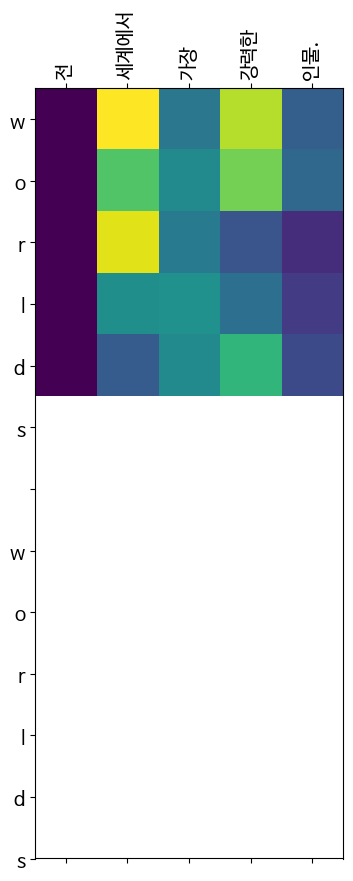

In [33]:
translate("전 세계에서 가장 강력한 인물.", model, kor_tokenizer, eng_tokenizer, max_len=30)

Input: 내가 도와줄까?
Predicted translation: addition regular smoke cant toeute


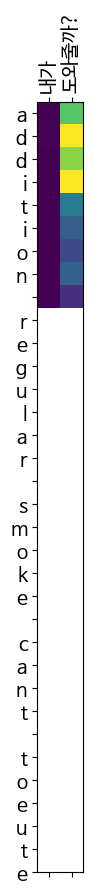

In [34]:
translate("내가 도와줄까?", model, kor_tokenizer, eng_tokenizer, max_len=30)

Input: 커피좀 주시겠어요?.
Predicted translation: than dozen ofsssssss


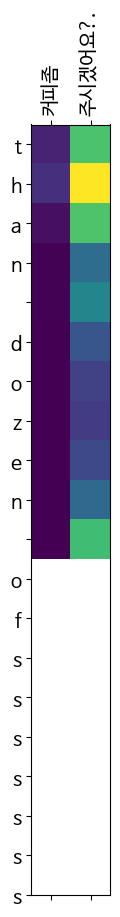

In [35]:
translate("커피좀 주시겠어요?.", model, kor_tokenizer, eng_tokenizer, max_len=30)

# 회고
로스를 줄이기 위해서 이것 저것 만져보니, 결국 로스만 엄청 커지고 번역을 하지 못하는 단계까지 와버렸습니다...
아무래도, 이건... 어디든 사용하기 적합하지 않은것일지도 모르겠네요...
